# Real Iligan Custom Mohring Route Preview

This notebook previews the custom Mohring route anchors on the **real Iligan CityGraph**, not the toy city.

It follows the same real-map assets used in `diagnostic_core.ipynb`:

- `configs/profile_p1.yaml`
- `rnd/pkl/profile_p1.pkl`
- `rnd/pkl/ddm_8am.pkl`

The route anchors are snapped to **real drivable CityGraph nodes only**, then connected using `CityGraph.find_shortest_path()`, which traverses drivable edges only.


In [ ]:
from pathlib import Path
import sys, json, pickle, math

# Run this notebook from the project root: Jeepney-Route-System-Optimization/
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = Path('configs/profile_p1.yaml')
CITY_PKL = Path('rnd/pkl/profile_p1.pkl')
DDM_PKL = Path('rnd/pkl/ddm_8am.pkl')
ROUTES_JSON = Path('configs/custom_mohring_routes.json')
OUTPUT_DIR = Path('outputs/iligan_custom_route')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ROUTE_COUNTS = [4, 8, 16, 32, 38]
IMAGE_SIZE = 1200

for required in [CONFIG_PATH, CITY_PKL, DDM_PKL, ROUTES_JSON]:
    if not required.exists():
        raise FileNotFoundError(
            f'Missing required file: {required}\n'
            'Make sure this notebook is inside the project root and that the real Iligan pickle/config files exist.'
        )

print('Project root:', PROJECT_ROOT)
print('Using real CityGraph pickle:', CITY_PKL)
print('Using real DDM pickle:', DDM_PKL)
print('Using custom routes JSON:', ROUTES_JSON)


Project root: /Users/joshuaradzadlaon/Documents/vscode/Jeepney-Route-System-Optimization
Using real CityGraph pickle: rnd/pkl/profile_p1.pkl
Using real DDM pickle: rnd/pkl/ddm_8am.pkl
Using custom routes JSON: configs/custom_mohring_routes.json


In [2]:
import yaml
from IPython.display import display
from scipy.spatial import cKDTree
import numpy as np

from utils.node import Node
from utils.directed_edge import DirEdge
from utils.route import Route
from utils.travel_graph import TravelGraph

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

with open(CITY_PKL, 'rb') as f:
    city = pickle.load(f)

with open(DDM_PKL, 'rb') as f:
    sampler = pickle.load(f)
sampler.city = city

with open(ROUTES_JSON, 'r', encoding='utf-8') as f:
    routes_payload = json.load(f)

print(city)
print(f'Total nodes: {len(city.nodes)}')
print(f'Total graph edges: {len(city.graph)}')
print(f'Drivable graph edges: {sum(1 for e in city.graph if getattr(e, "is_drivable", False))}')
print(f'DDM drivable nodes: {len(getattr(sampler, "drivable_nodes", []))}')


CityGraph(Iligan City) | Nodes: 36866 | Edges: 76310 (Drivable: 26024) | Landmarks: ['MSU-IIT', 'Robinsons Place']
Total nodes: 36866
Total graph edges: 76310
Drivable graph edges: 26024
DDM drivable nodes: 12933


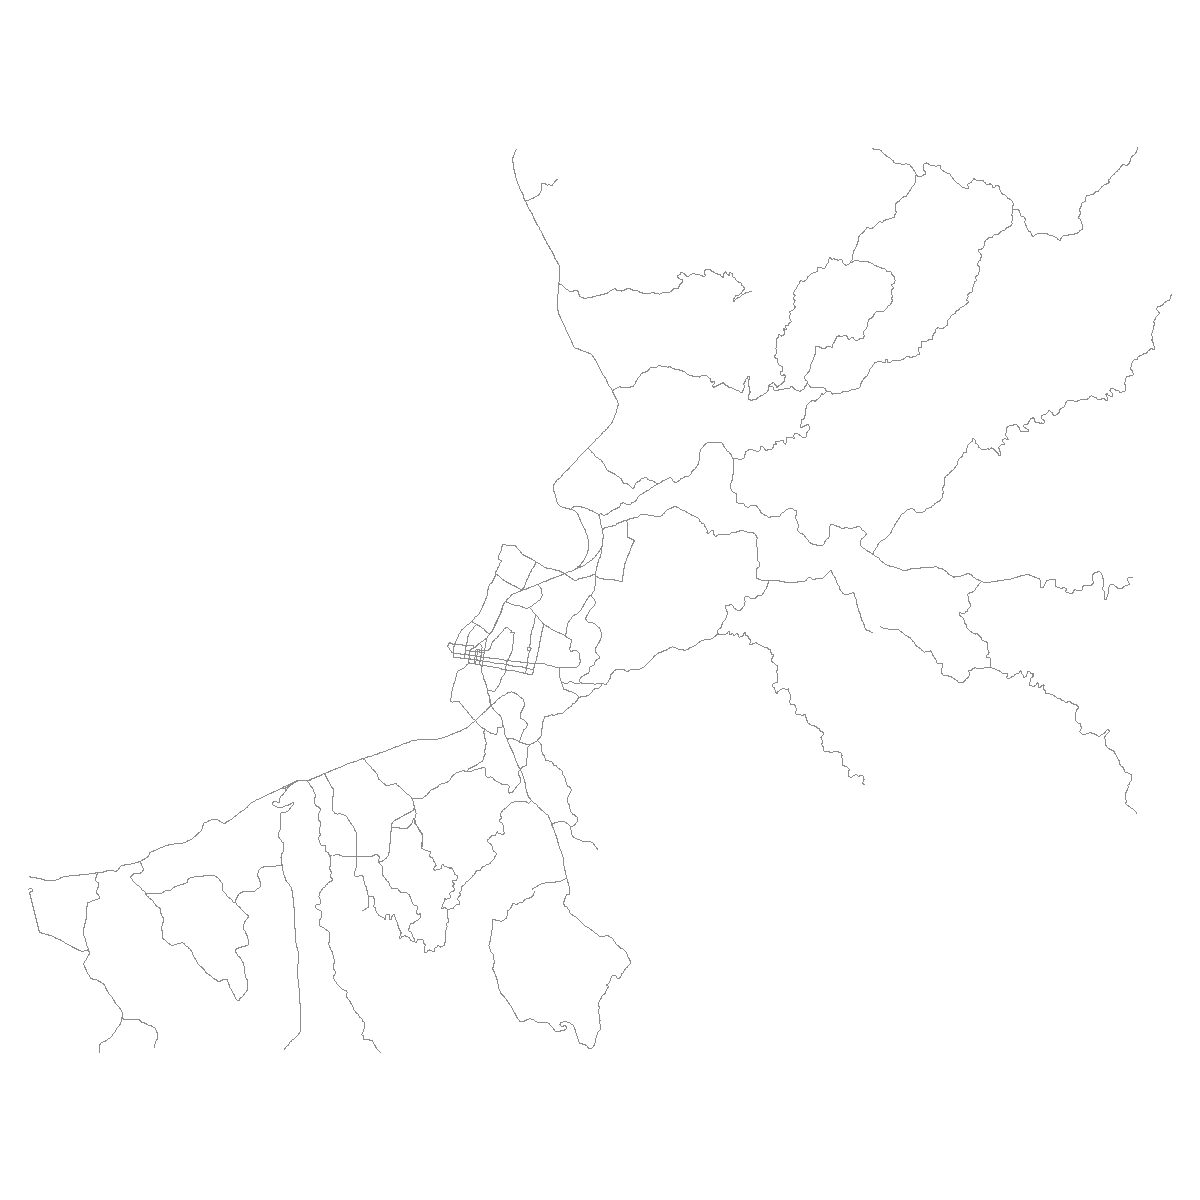

Saved: outputs/iligan_custom_route/real_iligan_drivable_only_base.png


In [3]:
# Show the real Iligan drivable-only base map.
context = city.get_bounds()
base_drivable = city.draw(size=IMAGE_SIZE, only_drivable=True)
display(base_drivable)
base_drivable.save(OUTPUT_DIR / 'real_iligan_drivable_only_base.png')
print('Saved:', OUTPUT_DIR / 'real_iligan_drivable_only_base.png')


In [4]:
def extract_drivable_nodes(city):
    drivable = set()
    for edge in city.graph:
        if getattr(edge, 'is_drivable', False):
            drivable.add(edge.start)
            drivable.add(edge.end)
    if not drivable:
        raise ValueError('The real CityGraph has zero drivable nodes.')
    return list(drivable)

DRIVABLE_NODES = extract_drivable_nodes(city)
DRIVABLE_COORDS = np.array([(node.lon, node.lat) for node in DRIVABLE_NODES], dtype=float)
DRIVABLE_TREE = cKDTree(DRIVABLE_COORDS)

def snap_to_nearest_drivable_node(lon, lat):
    dist, idx = DRIVABLE_TREE.query(np.array([[float(lon), float(lat)]], dtype=float))
    return DRIVABLE_NODES[int(idx[0])], float(dist[0])

def clean_consecutive_duplicates(nodes):
    cleaned = []
    for node in nodes:
        if not cleaned or node is not cleaned[-1]:
            cleaned.append(node)
    if len(cleaned) >= 2 and cleaned[-1] is cleaned[0]:
        cleaned.pop()
    return cleaned

def promote_base_path_to_layer2_route(base_path, route_id):
    if not base_path:
        raise ValueError(f'Route {route_id} produced an empty base path.')

    l2_path = []
    for edge in base_path:
        # Same pattern used by RouteGenerator._promote_to_route(): preserve the real drivable geometry,
        # then tag the promoted route edge as Layer 2 for Route validation.
        l2_edge = DirEdge(edge.start, edge.end, is_drivable=True, weight=getattr(edge, 'weight', None))
        setattr(l2_edge, 'layer', 2)
        if hasattr(edge, 'id'):
            l2_edge.id = f'{route_id}_{edge.id}'
        l2_path.append(l2_edge)

    for i in range(len(l2_path)):
        l2_path[i].next_edges.append(l2_path[(i + 1) % len(l2_path)])

    return Route(city, l2_path, id=route_id)

def build_real_drivable_route(route_item):
    route_id = route_item.get('id') or route_item.get('name') or 'custom_route'

    if 'coords_lonlat' in route_item:
        coords_lonlat = route_item['coords_lonlat']
    elif 'coordinates_lonlat' in route_item:
        coords_lonlat = route_item['coordinates_lonlat']
    elif 'coords_latlon' in route_item:
        coords_lonlat = [[lon, lat] for lat, lon in route_item['coords_latlon']]
    else:
        raise KeyError(f'Route {route_id} has no coords_lonlat or coords_latlon.')

    snapped_info = []
    snapped_nodes = []
    for lon, lat in coords_lonlat:
        node, snap_dist_deg = snap_to_nearest_drivable_node(lon, lat)
        snapped_nodes.append(node)
        snapped_info.append({
            'input_lon': lon, 'input_lat': lat,
            'snapped_lon': node.lon, 'snapped_lat': node.lat,
            'snap_dist_deg': snap_dist_deg,
        })

    waypoints = clean_consecutive_duplicates(snapped_nodes)
    if len(waypoints) < 2:
        raise ValueError(f'Route {route_id} collapsed to fewer than 2 distinct drivable nodes after snapping.')

    base_path = []
    for i in range(len(waypoints)):
        start = waypoints[i]
        end = waypoints[(i + 1) % len(waypoints)]
        if start is end:
            continue
        segment = city.find_shortest_path(start, end)
        if not segment:
            raise ValueError(f'No real drivable path for route {route_id} segment {i}.')
        # CityGraph.find_shortest_path already filters non-drivable edges, but we assert it for defense clarity.
        if not all(getattr(edge, 'is_drivable', False) for edge in segment):
            raise AssertionError(f'Route {route_id} segment {i} used a non-drivable edge.')
        base_path.extend(segment)

    route = promote_base_path_to_layer2_route(base_path, route_id)
    return route, snapped_info

def load_route_items_for_case(route_count):
    key = str(route_count)
    if 'route_sets' in routes_payload:
        return routes_payload['route_sets'][key]['routes']
    return routes_payload[key]

print(f'Drivable nodes available for snapping: {len(DRIVABLE_NODES)}')


Drivable nodes available for snapping: 12933



=== Building 4-route case on real Iligan drivable graph ===
  00. R00_Tubod_Tibanga: 224 drivable path edges
  01. R01_Tubod_Tominobo: 277 drivable path edges
  02. R02_Palao_Kiwalan: 488 drivable path edges
  03. R03_Buruun_Palao: 626 drivable path edges
Saved: outputs/iligan_custom_route/iligan_custom_routes_4.png


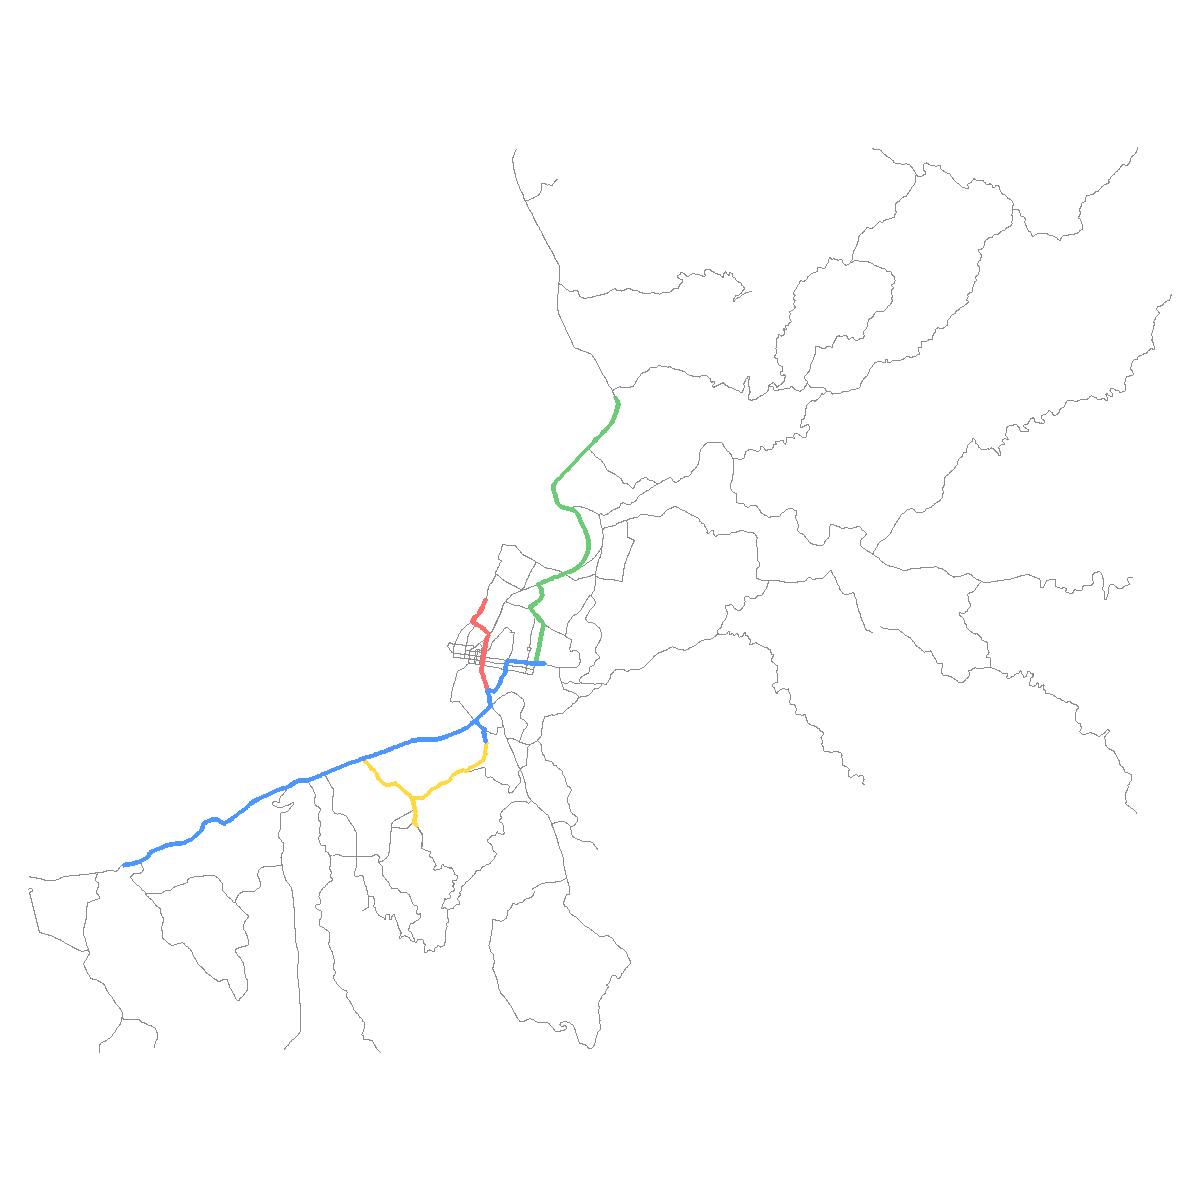

  TravelGraph OK: 193887 total travel-graph edges

=== Building 8-route case on real Iligan drivable graph ===
  00. R00_Tubod_Tibanga: 224 drivable path edges
  01. R01_Tubod_Tominobo: 277 drivable path edges
  02. R02_Palao_Kiwalan: 488 drivable path edges
  03. R03_Buruun_Palao: 626 drivable path edges
  04. R04_Tambacan_Tibanga: 124 drivable path edges
  05. R05_Tubod_Tipanoy: 481 drivable path edges
  06. R06_MariaCristina_Tubod: 286 drivable path edges
  07. R07_Palao_Luinab: 264 drivable path edges
Saved: outputs/iligan_custom_route/iligan_custom_routes_8.png


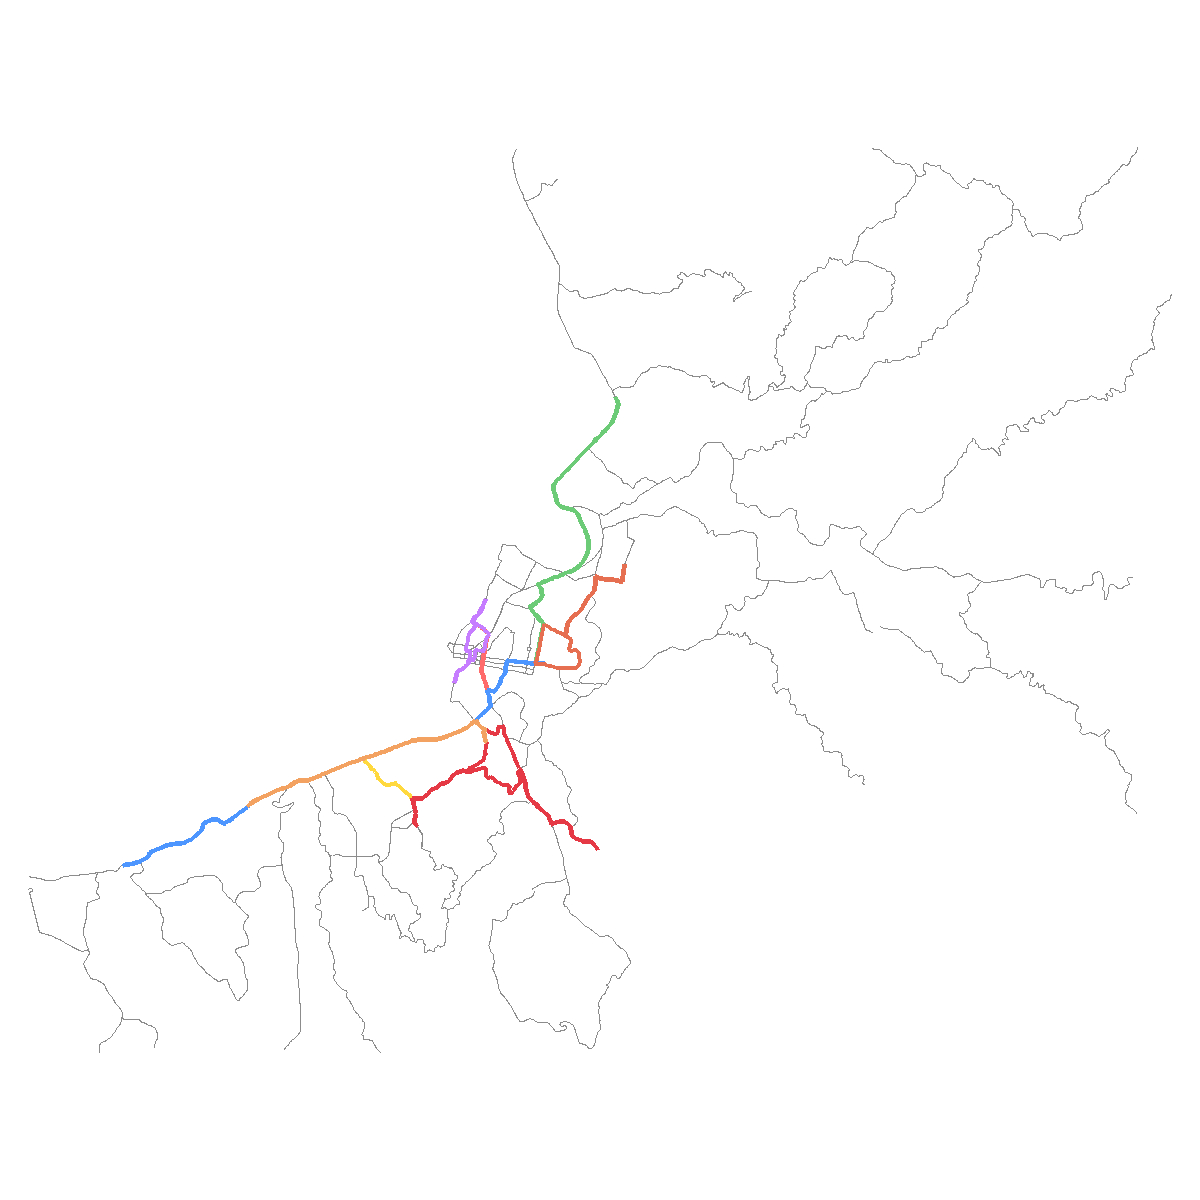

  TravelGraph OK: 197268 total travel-graph edges

=== Building 16-route case on real Iligan drivable graph ===
  00. R00_Tubod_Tibanga: 224 drivable path edges
  01. R01_Tubod_Tominobo: 277 drivable path edges
  02. R02_Palao_Kiwalan: 488 drivable path edges
  03. R03_Buruun_Palao: 626 drivable path edges
  04. R04_Tambacan_Tibanga: 124 drivable path edges
  05. R05_Tubod_Tipanoy: 481 drivable path edges
  06. R06_MariaCristina_Tubod: 286 drivable path edges
  07. R07_Palao_Luinab: 264 drivable path edges
  08. R08_Dalipuga_Palao: 624 drivable path edges
  09. R09_Buruun_Tubod: 632 drivable path edges
  10. R10_Tominobo_Tibanga: 324 drivable path edges
  11. R11_Tipanoy_Palao: 634 drivable path edges
  12. R12_Luinab_Tibanga: 260 drivable path edges
  13. R13_Bonbonon_Kiwalan: 556 drivable path edges
  14. R14_Ditucalan_Tubod: 784 drivable path edges
  15. R15_VillaVerde_Palao: 178 drivable path edges
Saved: outputs/iligan_custom_route/iligan_custom_routes_16.png


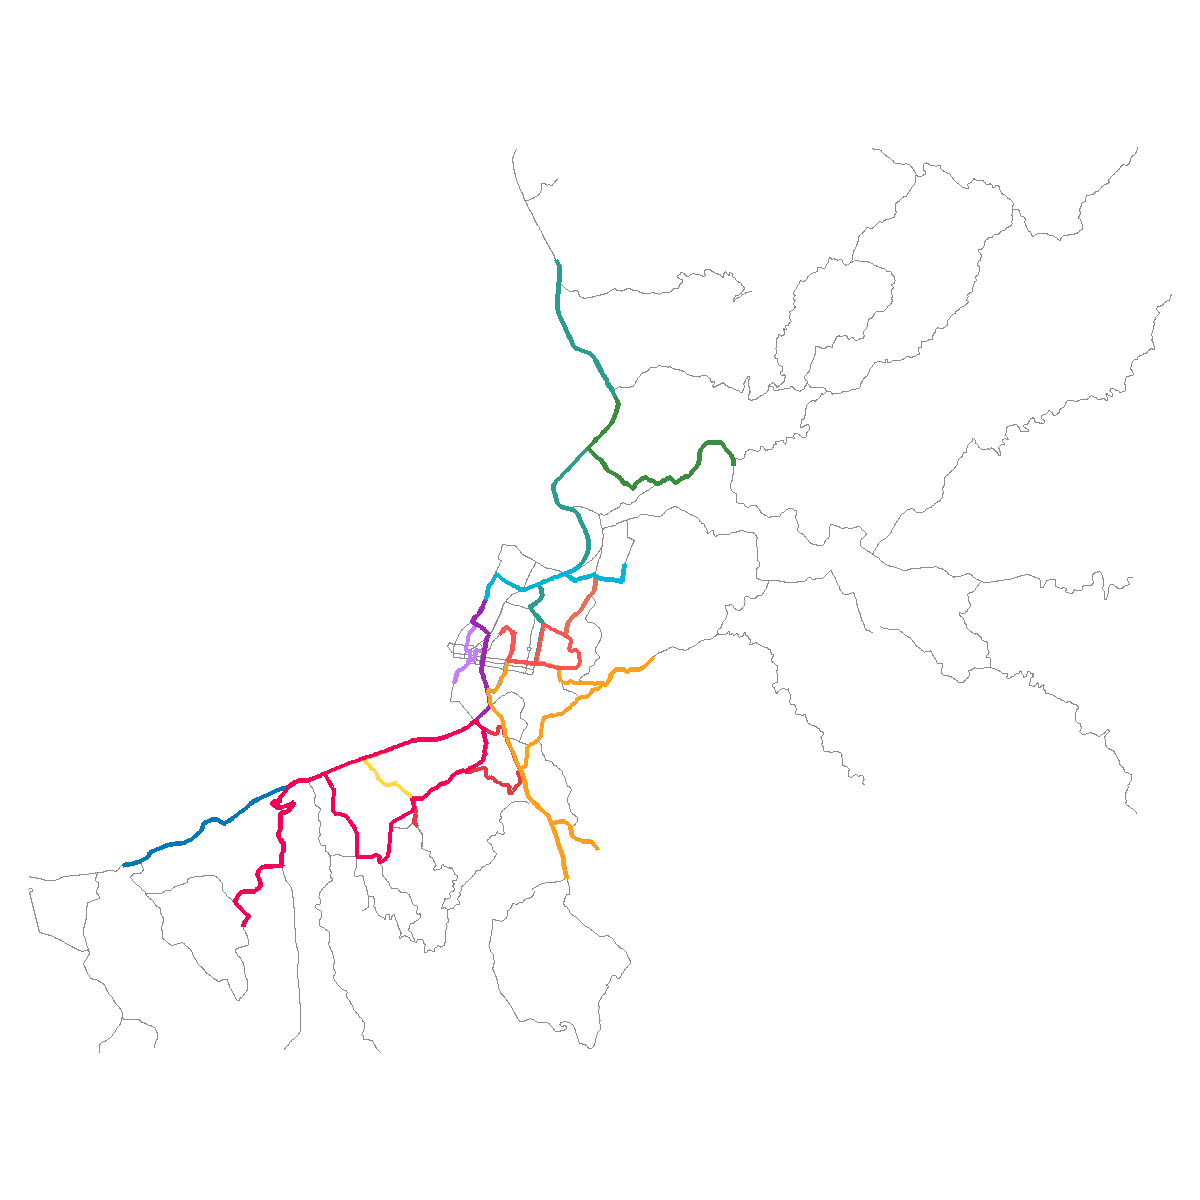

  TravelGraph OK: 208907 total travel-graph edges

=== Building 32-route case on real Iligan drivable graph ===
  00. R00_Tubod_Tibanga: 224 drivable path edges
  01. R01_Tubod_Tominobo: 277 drivable path edges
  02. R02_Palao_Kiwalan: 488 drivable path edges
  03. R03_Buruun_Palao: 626 drivable path edges
  04. R04_Tambacan_Tibanga: 124 drivable path edges
  05. R05_Tubod_Tipanoy: 481 drivable path edges
  06. R06_MariaCristina_Tubod: 286 drivable path edges
  07. R07_Palao_Luinab: 264 drivable path edges
  08. R08_Dalipuga_Palao: 624 drivable path edges
  09. R09_Buruun_Tubod: 632 drivable path edges
  10. R10_Tominobo_Tibanga: 324 drivable path edges
  11. R11_Tipanoy_Palao: 634 drivable path edges
  12. R12_Luinab_Tibanga: 260 drivable path edges
  13. R13_Bonbonon_Kiwalan: 556 drivable path edges
  14. R14_Ditucalan_Tubod: 784 drivable path edges
  15. R15_VillaVerde_Palao: 178 drivable path edges
  16. R16_UpperTominobo_Tubod: 664 drivable path edges
  17. R17_BagongSilang_Palao:

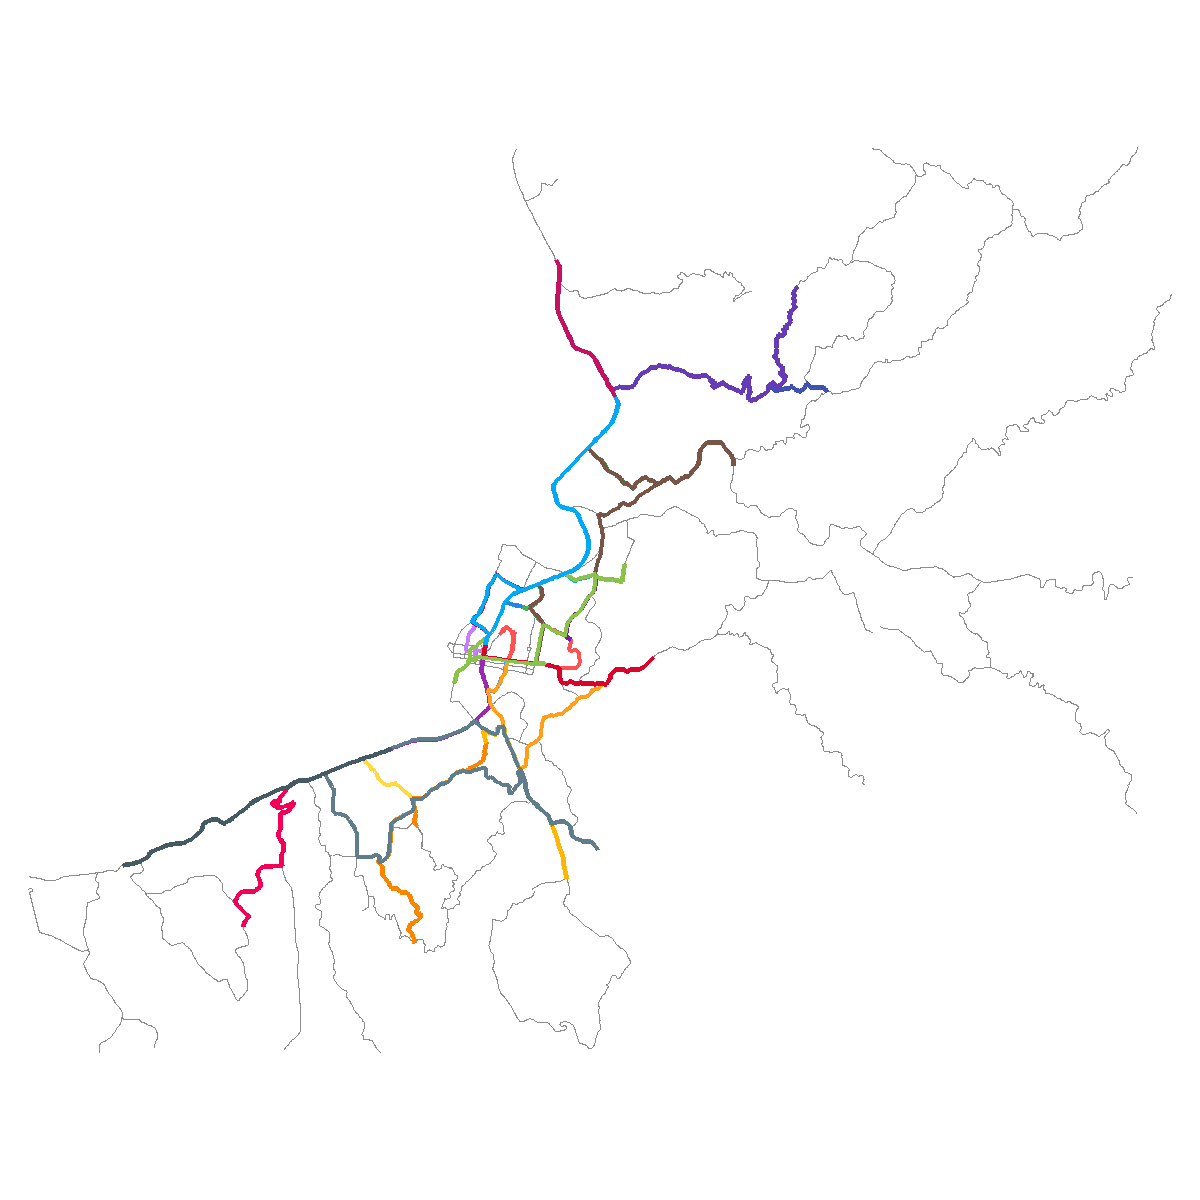

  TravelGraph OK: 231004 total travel-graph edges


In [5]:
# Build and preview all requested route-count cases on the real Iligan drivable map.
ROUTE_PALETTE = [
    '#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF', '#C77DFF', '#E63946', '#F4A261', '#E76F51',
    '#2A9D8F', '#0077B6', '#9C27B0', '#FF9F1C', '#00B4D8', '#388E3C', '#F50057', '#FF5252',
    '#FB8500', '#4CAF50', '#1E88E5', '#7B1FA2', '#D90429', '#FFB703', '#0096C7', '#00C9A7',
    '#3F51B5', '#673AB7', '#C51162', '#795548', '#607D8B', '#455A64', '#8BC34A', '#03A9F4',
]

real_route_sets = {}
route_snap_reports = {}

for route_count in ROUTE_COUNTS:
    print(f'\n=== Building {route_count}-route case on real Iligan drivable graph ===')
    route_items = load_route_items_for_case(route_count)
    routes = []
    snap_reports = []

    for idx, item in enumerate(route_items):
        route, snap_info = build_real_drivable_route(item)
        routes.append(route)
        snap_reports.append({'route_id': route.id, 'edge_count': len(route.path), 'snap_info': snap_info})
        print(f'  {idx:02d}. {route.id}: {len(route.path)} drivable path edges')

    real_route_sets[route_count] = routes
    route_snap_reports[route_count] = snap_reports

    img = city.draw(size=IMAGE_SIZE, only_drivable=True)
    for idx, route in enumerate(routes):
        route.draw(context=context, image=img, color=ROUTE_PALETTE[idx % len(ROUTE_PALETTE)], width=4)

    out_path = OUTPUT_DIR / f'iligan_custom_routes_{route_count}.png'
    img.save(out_path)
    print('Saved:', out_path)
    display(img)

    # Validate that these snapped routes can initialize a TravelGraph.
    tg = TravelGraph(cg=city, config=cfg.get('travel_graph', {}).copy(), routes=routes)
    print(f'  TravelGraph OK: {len(tg.travel_graph)} total travel-graph edges')


In [6]:
# Save snapped-coordinate audit files for thesis defense / appendix.
snap_report_path = OUTPUT_DIR / 'iligan_route_snap_report.json'
with open(snap_report_path, 'w', encoding='utf-8') as f:
    json.dump(route_snap_reports, f, indent=2)

manifest = {'route_sets': {}}
for route_count, routes in real_route_sets.items():
    manifest['route_sets'][str(route_count)] = {
        'routes': [
            {
                'id': route.id,
                'edge_count': len(route.path),
                'coords_lonlat': [[edge.start.lon, edge.start.lat] for edge in route.path] + [[route.path[-1].end.lon, route.path[-1].end.lat]],
            }
            for route in routes
        ]
    }

manifest_path = OUTPUT_DIR / 'iligan_snapped_route_manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Saved:', snap_report_path)
print('Saved:', manifest_path)


Saved: outputs/iligan_custom_route/iligan_route_snap_report.json
Saved: outputs/iligan_custom_route/iligan_snapped_route_manifest.json
